# Hurricane Helene (2024) — TC Track & Intensity Verification

Track Hurricane Helene's center and intensity over a **72 h** forecast from **AIFS2**, **SFNO**,
and **Aurora**, compared against ERA5 reanalysis at every 6-hourly step from initialization to
the Florida Big Bend landfall (`2024-09-27 00:00 UTC`):

- **Intensity** — minimum MSLP within the domain (central pressure).
- **Position** — location of the maximum **850 hPa relative vorticity** (storm center).

**Pipeline:** inference (`run.deterministic` → Zarr, every step) → post-process (vorticity center +
min-MSLP in numpy) → track/intensity tables and plots.

| Lead | Init time (UTC)  | Steps (6 h) |
|------|------------------|-------------|
| 72 h | 2024-09-24 00:00 | 12          |

In [2]:
import os

# Must be set BEFORE importing torch.
os.environ["FORCE_CUDA_EXTENSION"] = "1"
os.environ["TORCH_CUDA_ARCH_LIST"] = "8.9"
os.environ["CUDA_HOME"] = "/usr/local/cuda"
os.environ["EARTH2STUDIO_CACHE"] = os.path.expanduser("~/.cache/earth2studio")
os.environ["CUFILE_ENV_PATH_JSON"] = "/dev/null"

In [3]:
from pathlib import Path
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import torch
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from tqdm import tqdm
from scipy.ndimage import gaussian_filter

from earth2studio.models.px import AIFS2, SFNO, Aurora
from earth2studio.data import WB2ERA5, ARCO, fetch_data, prep_data_array
from earth2studio.utils.time import to_time_array
from earth2studio.utils.coords import map_coords
import earth2studio.run as run
from earth2studio.io import ZarrBackend

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"GPU   : {torch.cuda.get_device_name(0)}")
print(f"VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print("DONE")

/home/jovyan/hurricane-forecasts/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm

Warp DeprecationWarning: The symbol `warp.context.Device` will soon be removed from the public API. Use `warp.Device` instead.Device: cuda
GPU   : NVIDIA L40
VRAM  : 47.7 GB
DONE

In [4]:
STORM_NAME = "Helene"

VERIFICATION_TIME = datetime(2024, 9, 27, 0)   # landfall = verification (valid) time

LEAD_TIMES_H = [72]    # 72h only for now (168/240 retired; list kept parameterized)
LEAD_H = LEAD_TIMES_H[0]

INIT_TIMES = {h: VERIFICATION_TIME - timedelta(hours=h) for h in LEAD_TIMES_H}
N_STEPS    = {h: h // 6 for h in LEAD_TIMES_H}

VALID_TIMES = [INIT_TIMES[LEAD_H] + timedelta(hours=6 * k) for k in range(N_STEPS[LEAD_H] + 1)]

OUT_DIR = Path("./outputs/helene")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# (lon_min, lon_max, lat_min, lat_max), lon in [-180, 180].
DOMAIN = (-100, -65, 15, 40)

# Tighter box than DOMAIN, used only for center-finding/the track map — must exclude other
# systems that can dominate a wider box. Hurricane John sat at the SW corner (16N, 99W) on
# 2024-09-24, so the west edge is trimmed to keep it out.
TRACK_DOMAIN = (-95, -76, 15, 35)

LANDFALL_LAT = 30.0
LANDFALL_LON = -83.7

MODELS = ["AIFS2", "SFNO", "Aurora"]
FILE_PREFIX = {"AIFS2": "aifs2", "SFNO": "sfno", "Aurora": "aurora"}

FIELD_VARS = ["msl", "u10m", "v10m", "u850", "v850"]

VORT_SMOOTH_SIGMA = 1.5      # gaussian_filter sigma (grid cells) before vorticity argmax
SEARCH_RADIUS_DEG = 5.0      # moving search-box half-width (deg) around the previous center

# Kept for reference; field-plot cells that used them have been removed.
MSLP_VMIN, MSLP_VMAX = 960.0, 1020.0
MSLP_LEVELS = np.arange(MSLP_VMIN, MSLP_VMAX + 1, 4)

print(f"{STORM_NAME}: lead={LEAD_H}h  init={INIT_TIMES[LEAD_H]}  steps={N_STEPS[LEAD_H]}  "
      f"valid_times={len(VALID_TIMES)} ({VALID_TIMES[0]:%Y-%m-%d %HZ} → {VALID_TIMES[-1]:%Y-%m-%d %HZ})")

Helene: lead=72h  init=2024-09-24 00:00:00  steps=12  valid_times=13 (2024-09-24 00Z → 2024-09-27 00Z)

In [5]:
def extract_field(x, coords, variables, domain):
    """Extract `variables` over `domain` from a model/analysis state (x, coords).

    Returns an xarray.Dataset on (lat, lon), sorted ascending, msl in Pa.
    `domain` = (lon_min, lon_max, lat_min, lat_max) in [-180, 180].
    Used for the ERA5 truth fetch (per valid time).
    """
    if hasattr(x, "detach"):
        x = x.detach().cpu().numpy()
    dims = list(coords.keys())
    vax = dims.index("variable")
    var_names = list(coords["variable"])
    lat = np.asarray(coords["lat"], dtype=float)
    lon = np.asarray(coords["lon"], dtype=float) % 360.0

    lon_min, lon_max, lat_min, lat_max = domain
    lon0, lon1 = lon_min % 360.0, lon_max % 360.0
    lat_mask = (lat >= lat_min) & (lat <= lat_max)
    lon_mask = (lon >= min(lon0, lon1)) & (lon <= max(lon0, lon1))

    data_vars = {}
    for v in variables:
        field = np.squeeze(np.take(x, var_names.index(v), axis=vax))
        data_vars[v] = (("lat", "lon"), field[np.ix_(lat_mask, lon_mask)])

    ds = xr.Dataset(data_vars, coords={"lat": lat[lat_mask], "lon": lon[lon_mask]})
    return ds.sortby("lat").sortby("lon")


def domain_output_coords(model, domain, variables):
    """Build `output_coords` for run.deterministic: subselect `variables` + the domain lat/lon box.

    Lat/lon values are taken from the model's own output grid so map_coords matches them exactly.
    `domain` = (lon_min, lon_max, lat_min, lat_max) in [-180, 180]; model lon is in 0–360.
    """
    g = model.output_coords(model.input_coords())
    glat = np.asarray(g["lat"], dtype=float)
    glon = np.asarray(g["lon"], dtype=float)
    lon_min, lon_max, lat_min, lat_max = domain
    lo0, lo1 = lon_min % 360.0, lon_max % 360.0
    box_lat = glat[(glat >= lat_min) & (glat <= lat_max)]
    box_lon = glon[(glon >= min(lo0, lo1)) & (glon <= max(lo0, lo1))]
    return {"variable": np.array(variables), "lat": box_lat, "lon": box_lon}


def run_track_inference(model, data_source, init_time, nsteps, store_path,
                        domain=DOMAIN, variables=FIELD_VARS):
    """Integrate `model` for `nsteps` 6h steps from `init_time`, writing EVERY step
    (msl + 10m/850hPa winds over the domain box) to a Zarr store via run.deterministic.

    Skips if the store already exists. run.deterministic fetches initial conditions the same
    way the old helper did (`lead_time` from input_coords), so AIFS2-from-CDS and Aurora's
    two-frame init need no special handling.
    """
    store_path = Path(store_path)
    if store_path.exists():
        print(f"  cached → {store_path}")
        return
    out_coords = domain_output_coords(model, domain, variables)
    io = ZarrBackend(str(store_path), backend_kwargs={"overwrite": True})
    run.deterministic([init_time], nsteps, model, data_source, io,
                      output_coords=out_coords, device=DEVICE)
    print(f"  saved  → {store_path}  (vars={variables}, steps={nsteps + 1})")

In [6]:
def run_era5_track(data_source, valid_times, save_path, variables=FIELD_VARS):
    """Fetch ERA5 truth fields over DOMAIN at each of `valid_times` and concat on valid_time.

    Reuses extract_field per single time (avoids the time-axis squeeze issue), keeps the
    corrupted-cache-chunk fallback. Cached to a single NetCDF (valid_time, lat, lon).
    """
    if Path(save_path).exists():
        print(f"  cached → {save_path}")
        return xr.open_dataset(save_path)

    snaps = []
    for vt in tqdm(valid_times, desc="ERA5 valid times"):
        try:
            da = data_source(vt, list(variables))
        except RuntimeError:
            # Corrupted cache chunk — retry with a fresh uncached download.
            da = ARCO(cache=False)(vt, list(variables))
        x, coords = prep_data_array(da, device=DEVICE)
        snap = extract_field(x, coords, variables, DOMAIN)
        snaps.append(snap.expand_dims(valid_time=[np.datetime64(vt)]))

    ds = xr.concat(snaps, dim="valid_time")
    ds.to_netcdf(save_path)
    print(f"  saved  → {save_path}  ({ds.sizes['valid_time']} valid times)")
    return ds

In [7]:
# WB2ERA5 has a hard cutoff of 2023-01-11; Helene's init times are in Sep 2024, so use ARCO.
data_source = ARCO(cache=True)

In [8]:
from earth2studio.data import CDS
from aifs2_era5 import patch_cds_lexicon_for_aifs2, ZERO_FILL_WAVE_VARS

# AIFS v2 needs 16 inputs the stock CDS lexicon lacks: t10/u10/v10/z10 and snow depth are
# fetched for real, the 11 ocean-wave inputs are zero-filled (idempotent patch).
zeroed = patch_cds_lexicon_for_aifs2()
print("AIFS v2 CDS lexicon patched; zero-filled wave inputs:", zeroed)

# AIFS2 needs ECMWF analysis fields (incl. soil) not in ARCO -- initialize it from CDS.
aifs_data_source = CDS(cache=True)

AIFS v2 CDS lexicon patched; zero-filled wave inputs: ['swh', 'mwp', 'cdww', 'cos_mwd', 'sin_mwd', 'h1012', 'h1214', 'h1417', 'h1721', 'h2125', 'h2530']

## AIFS2 forecasts

AIFS2 (ECMWF AIFS Single v2.0) — GNN encoder/decoder + sliding-window transformer
processor. Initialized from CDS analysis fields.

In [9]:
%%time
aifs2 = AIFS2.load_model(AIFS2.load_default_package())

CPU times: user 5.48 s, sys: 992 ms, total: 6.47 s
Wall time: 1min 9s

In [10]:
%%time
run_track_inference(
    aifs2, aifs_data_source,
    INIT_TIMES[LEAD_H], N_STEPS[LEAD_H],
    OUT_DIR / "aifs2_72h.zarr",
)

  cached → outputs/helene/aifs2_72h.zarr
CPU times: user 384 μs, sys: 46 μs, total: 430 μs
Wall time: 342 μs

In [11]:
import gc
del aifs2
gc.collect()
torch.cuda.empty_cache()
print(f"GPU memory freed: {torch.cuda.memory_allocated()/1e9:.1f} GB allocated, {torch.cuda.memory_reserved()/1e9:.1f} GB reserved")

GPU memory freed: 0.0 GB allocated, 0.0 GB reserved

## Aurora forecasts

Aurora (Microsoft) — 0.25° foundation model, 6-hourly autoregressive. Needs two
initial frames (t−6 h, t); initialized from ARCO ERA5. The `gpu:48gb` badge is at the
L40 limit, so only one model is kept resident at a time.

In [12]:
%%time
aurora = Aurora.load_model(Aurora.load_default_package())

CPU times: user 21.7 s, sys: 4.77 s, total: 26.5 s
Wall time: 1min 1s

In [13]:
%%time
run_track_inference(
    aurora, data_source,
    INIT_TIMES[LEAD_H], N_STEPS[LEAD_H],
    OUT_DIR / "aurora_72h.zarr",
)

  cached → outputs/helene/aurora_72h.zarr
CPU times: user 215 μs, sys: 35 μs, total: 250 μs
Wall time: 216 μs

In [14]:
del aurora
gc.collect()
torch.cuda.empty_cache()
print(f"GPU memory freed: {torch.cuda.memory_allocated()/1e9:.1f} GB allocated, {torch.cuda.memory_reserved()/1e9:.1f} GB reserved")

GPU memory freed: 0.0 GB allocated, 0.0 GB reserved

## SFNO forecasts

SFNO (NVIDIA) — Spherical Fourier Neural Operator using spectral convolutions
on the sphere. Efficient O(N log N) transforms via spherical harmonics.

In [15]:
%%time
sfno = SFNO.load_model(SFNO.load_default_package())

CPU times: user 7.93 s, sys: 5.21 s, total: 13.1 s
Wall time: 1min 16s

In [16]:
%%time
run_track_inference(
    sfno, data_source,
    INIT_TIMES[LEAD_H], N_STEPS[LEAD_H],
    OUT_DIR / "sfno_72h.zarr",
)

  cached → outputs/helene/sfno_72h.zarr
CPU times: user 203 μs, sys: 0 ns, total: 203 μs
Wall time: 167 μs

In [17]:
del sfno
gc.collect()
torch.cuda.empty_cache()
print(f"GPU memory freed: {torch.cuda.memory_allocated()/1e9:.1f} GB allocated, {torch.cuda.memory_reserved()/1e9:.1f} GB reserved")

GPU memory freed: 0.0 GB allocated, 0.0 GB reserved

## ERA5 truth track

Fetch ERA5 fields at every 6-hourly valid time across the window — the reference track each model is compared against.

In [18]:
%%time
era5_track = run_era5_track(
    data_source, VALID_TIMES,
    OUT_DIR / "era5_track_72h.nc",
)

  cached → outputs/helene/era5_track_72h.ncCPU times: user 23.5 ms, sys: 7.42 ms, total: 30.9 ms
Wall time: 380 ms

## Load saved fields
Reload-safe: works whether you just ran inference or restarted the kernel.

In [19]:
def load_model_track(store_path, init_time):
    ds = xr.open_zarr(store_path, consolidated=False).squeeze("time", drop=True)
    vt = np.datetime64(init_time) + ds["lead_time"].values            # init + lead → valid time
    ds = ds.assign_coords(valid_time=("lead_time", vt)).swap_dims({"lead_time": "valid_time"})
    return ds.sortby("lat").sortby("lon")

model_tracks = {
    m: load_model_track(OUT_DIR / f"{FILE_PREFIX[m]}_72h.zarr", INIT_TIMES[LEAD_H])
    for m in MODELS
}
era5_track = xr.open_dataset(OUT_DIR / "era5_track_72h.nc").sortby("lat").sortby("lon")

for m in MODELS:
    ds = model_tracks[m]
    print(f"{m:8s} steps={ds.sizes['valid_time']:2d}  msl{tuple(ds['msl'].shape)}  "
          f"vars={list(ds.data_vars)}")
print(f"ERA5     steps={era5_track.sizes['valid_time']:2d}  msl{tuple(era5_track['msl'].shape)}")

AIFS2    steps=13  msl(13, 101, 141)  vars=['v10m', 'u10m', 'u850', 'msl', 'v850']
SFNO     steps=13  msl(13, 101, 141)  vars=['u10m', 'v10m', 'v850', 'msl', 'u850']
Aurora   steps=13  msl(13, 101, 141)  vars=['v850', 'u850', 'u10m', 'v10m', 'msl']
ERA5     steps=13  msl(13, 101, 141)

## Track & intensity diagnostics

Post-processing only (no GPU), over **`TRACK_DOMAIN`**. For each 6-hourly step:
- **position** = smoothed **850 hPa relative-vorticity maximum**, gated to ±`SEARCH_RADIUS_DEG` around the previous center;
- **intensity** = **minimum MSLP** (hPa) in that gated box.

Each model track is then compared to ERA5 (position error in km, intensity error in hPa).

In [20]:
R_EARTH_M = 6.371e6
R_EARTH_KM = 6371.0


def crop_to(ds, domain):
    """Crop a (…, lat, lon) Dataset to `domain`=(lon_min,lon_max,lat_min,lat_max) in [-180,180].
    Data lon is 0–360 ascending, so convert the box edges with % 360 before slicing."""
    lon_min, lon_max, lat_min, lat_max = domain
    return ds.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min % 360.0, lon_max % 360.0))


def relative_vorticity(u, v, lat, lon):
    """850-hPa relative vorticity ζ = ∂v/∂x − ∂u/∂y on a regular lat/lon grid (s⁻¹).

    u, v : (nlat, nlon) arrays on ascending lat/lon (m/s). lat, lon : 1-D degrees, ascending.
    Spherical metric terms: dx = R·cosφ·dλ, dy = R·dφ. NH cyclonic ζ > 0.
    """
    lat_r = np.radians(np.asarray(lat, float))
    lon_r = np.radians(np.asarray(lon, float))
    dphi = np.gradient(lat_r)
    dlam = np.gradient(lon_r)
    dy = R_EARTH_M * dphi
    dx = R_EARTH_M * np.cos(lat_r)[:, None] * dlam[None, :]
    dv_dx = np.gradient(v, axis=1) / dx
    du_dy = np.gradient(u, axis=0) / dy[:, None]
    return dv_dx - du_dy


def haversine_km(lat1, lon1, lat2, lon2):
    """Great-circle distance (km); inputs may be scalars or arrays (degrees)."""
    p1 = np.radians(lat1); p2 = np.radians(lat2)
    dphi = np.radians(np.asarray(lat2) - np.asarray(lat1))
    dlam = np.radians(np.asarray(lon2) - np.asarray(lon1))
    a = np.sin(dphi / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dlam / 2) ** 2
    return 2 * R_EARTH_KM * np.arcsin(np.sqrt(a))


def storm_center_intensity(ds_step, prev_center=None,
                           search_radius_deg=SEARCH_RADIUS_DEG, smooth_sigma=VORT_SMOOTH_SIGMA):
    """Locate the TC center (smoothed 850-hPa vorticity max) and intensity (min MSLP) for one step.

    prev_center=(lat,lon) gates BOTH the vorticity-max and MSLP-min searches to a ±search_radius_deg
    box around it (continuity); None searches the whole (already-cropped) box — used at step 0.
    Returns center_lat/lon, min_mslp_hpa, mslp_lat/lon (separation cross-check), on_edge.
    """
    lat = ds_step["lat"].values; lon = ds_step["lon"].values
    u = ds_step["u850"].values; v = ds_step["v850"].values
    mslp = ds_step["msl"].values / 100.0                     # Pa → hPa

    zeta = relative_vorticity(u, v, lat, lon)
    if smooth_sigma:
        zeta = gaussian_filter(zeta, sigma=smooth_sigma)

    if prev_center is not None:                              # moving search box (continuity gate)
        plat, plon = prev_center
        lat_ok = np.abs(lat - plat) <= search_radius_deg
        dlon = np.abs(((lon - plon + 180.0) % 360.0) - 180.0)
        lon_ok = dlon <= search_radius_deg
        mask = lat_ok[:, None] & lon_ok[None, :]
    else:
        mask = np.ones((lat.size, lon.size), dtype=bool)

    zeta_s = np.where(mask, zeta, -np.inf)                   # gate position (vorticity max) …
    mslp_s = np.where(mask, mslp, np.inf)                    # … and intensity (MSLP min)

    iy, ix = np.unravel_index(np.nanargmax(zeta_s), zeta.shape)
    on_edge = iy in (0, lat.size - 1) or ix in (0, lon.size - 1)
    im, jm = np.unravel_index(np.nanargmin(mslp_s), mslp.shape)
    return {
        "center_lat": float(lat[iy]),
        "center_lon": float(((lon[ix] + 180.0) % 360.0) - 180.0),    # → [-180,180]
        "min_mslp_hpa": float(mslp[im, jm]),
        "mslp_lat": float(lat[im]),
        "mslp_lon": float(((lon[jm] + 180.0) % 360.0) - 180.0),
        "on_edge": bool(on_edge),
    }


def track_from_dataset(ds_ts, seed_center=None):
    """Walk a (valid_time, lat, lon) Dataset forward → per-step center/intensity DataFrame.

    seed_center seeds step 0's search box; None lets step 0 take the global max in the box
    (fine once the box is tight enough to contain only the target storm)."""
    recs = []; prev = seed_center
    for t in ds_ts["valid_time"].values:
        ci = storm_center_intensity(ds_ts.sel(valid_time=t), prev_center=prev)
        ci["valid_time"] = pd.Timestamp(t)
        recs.append(ci)
        prev = (ci["center_lat"], ci["center_lon"])
    return pd.DataFrame(recs)


def build_tracks(model_tracks, era5_track, track_domain=None):
    """ERA5 + each model track over TRACK_DOMAIN (tighter box that excludes other systems).

    ERA5 takes the global vorticity max at step 0; each model is seeded from the ERA5 step-0
    center (disambiguates a weak init step without biasing the track, since the ±gate is wide).
    """
    td = track_domain if track_domain is not None else TRACK_DOMAIN
    era5_df = track_from_dataset(crop_to(era5_track, td), seed_center=None)
    seed = (float(era5_df.iloc[0]["center_lat"]), float(era5_df.iloc[0]["center_lon"]))
    model_dfs = {m: track_from_dataset(crop_to(ds, td), seed_center=seed)
                 for m, ds in model_tracks.items()}
    return era5_df, model_dfs


def track_skill_table(era5_df, model_dfs):
    """Per model: position-error (km) mean/max and intensity bias/RMSE (hPa) vs ERA5.

    Rows are compared positionally, so all DataFrames must share the same valid_time grid.
    """
    rows = []
    for m, df in model_dfs.items():
        pos = haversine_km(df["center_lat"].values, df["center_lon"].values,
                           era5_df["center_lat"].values, era5_df["center_lon"].values)
        dI = df["min_mslp_hpa"].values - era5_df["min_mslp_hpa"].values
        rows.append({
            "Model": m,
            "Pos mean (km)": round(float(np.mean(pos)), 1),
            "Pos max (km)": round(float(np.max(pos)), 1),
            "Intensity bias (hPa)": round(float(np.mean(dI)), 2),
            "Intensity RMSE (hPa)": round(float(np.sqrt(np.mean(dI ** 2))), 2),
        })
    return pd.DataFrame(rows)

In [21]:
def plot_tracks(era5_df, model_dfs, domain, save_path=None):
    """Storm-center tracks (850 hPa vorticity max) — ERA5 vs each model — over the domain."""
    fig = plt.figure(figsize=(8, 7))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="0.15")
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor="0.4")
    ax.set_extent(domain, crs=ccrs.PlateCarree())

    ax.plot(era5_df["center_lon"], era5_df["center_lat"], "-o", color="k", lw=2.5, ms=4,
            label="ERA5", transform=ccrs.PlateCarree(), zorder=6)
    for m, df in model_dfs.items():
        ax.plot(df["center_lon"], df["center_lat"], "-o", lw=1.5, ms=3,
                label=m, transform=ccrs.PlateCarree(), zorder=5)
    ax.plot(LANDFALL_LON, LANDFALL_LAT, marker="*", color="red", ms=16,
            markeredgecolor="white", markeredgewidth=0.8,
            transform=ccrs.PlateCarree(), zorder=10)

    gl = ax.gridlines(draw_labels=True, linewidth=0.2, color="0.7")
    gl.top_labels = gl.right_labels = False
    ax.legend(loc="best", fontsize=9)
    ax.set_title(f"{STORM_NAME} — {LEAD_H} h forecast tracks (850 hPa vorticity centers) vs ERA5")
    if save_path:
        fig.savefig(str(save_path), dpi=150, bbox_inches="tight"); print(f"saved → {save_path}")
    plt.show()


def plot_intensity(era5_df, model_dfs, save_path=None):
    """Intensity (min MSLP) vs lead time — ERA5 vs each model."""
    fig, ax = plt.subplots(figsize=(8, 4.5))
    lead = np.arange(len(era5_df)) * 6
    ax.plot(lead, era5_df["min_mslp_hpa"], "-o", color="k", lw=2.5, label="ERA5")
    for m, df in model_dfs.items():
        ax.plot(lead, df["min_mslp_hpa"], "-o", lw=1.5, label=m)
    ax.set_xlabel("Lead time (h)"); ax.set_ylabel("Min MSLP (hPa)")
    ax.set_xticks(lead)
    ax.invert_yaxis(); ax.grid(alpha=0.3); ax.legend(fontsize=9)
    ax.set_title(f"{STORM_NAME} — Minimum MSLP vs Lead Time")
    if save_path:
        fig.savefig(str(save_path), dpi=150, bbox_inches="tight"); print(f"saved → {save_path}")
    plt.show()


def plot_position_error(era5_df, model_dfs, save_path=None):
    """Track position error (haversine km) vs lead time — each model vs ERA5."""
    fig, ax = plt.subplots(figsize=(8, 4.5))
    lead = np.arange(len(era5_df)) * 6
    for m, df in model_dfs.items():
        err = haversine_km(df["center_lat"].values, df["center_lon"].values,
                           era5_df["center_lat"].values, era5_df["center_lon"].values)
        ax.plot(lead, err, "-o", lw=1.5, label=m)
    ax.set_xlabel("Lead time (h)"); ax.set_ylabel("Position error (km)")
    ax.set_xticks(lead)
    ax.grid(alpha=0.3); ax.legend(fontsize=9)
    ax.set_title(f"{STORM_NAME} — track position error vs ERA5")
    if save_path:
        fig.savefig(str(save_path), dpi=150, bbox_inches="tight"); print(f"saved → {save_path}")
    plt.show()

In [22]:
era5_df, model_dfs = build_tracks(model_tracks, era5_track)

df_track = track_skill_table(era5_df, model_dfs)
print(f"\n=== {STORM_NAME}: {LEAD_H} h track skill vs ERA5 "
      f"(vorticity center, min-MSLP intensity) ===\n")
print(df_track.to_string(index=False))

for label, df in {"ERA5": era5_df, **model_dfs}.items():
    n_edge = int(df["on_edge"].sum())
    if n_edge:
        print(f"{label}: {n_edge} step(s) with center on domain edge")


=== Helene: 72 h track skill vs ERA5 (vorticity center, min-MSLP intensity) ===

 Model  Pos mean (km)  Pos max (km)  Intensity bias (hPa)  Intensity RMSE (hPa)
 AIFS2           43.3          96.7                  3.64                  4.47
  SFNO           78.8         211.9                  4.54                  5.74
Aurora           50.8         185.9                  5.40                  6.94

saved → outputs/helene/track_map_72h.png

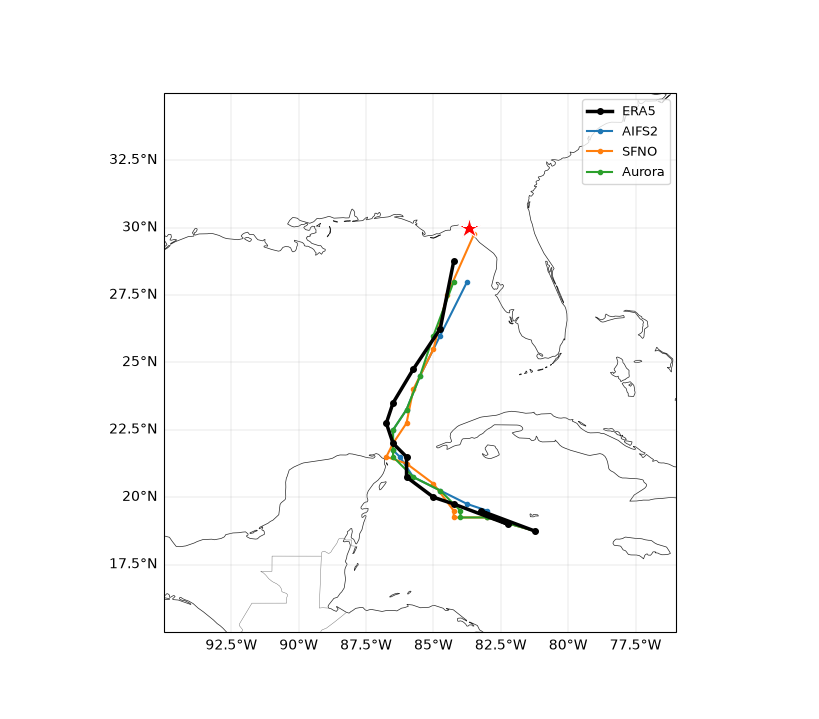

In [23]:
plot_tracks(era5_df, model_dfs, TRACK_DOMAIN, save_path=OUT_DIR / "track_map_72h.png")

In [25]:
# plot_intensity(era5_df, model_dfs, save_path=OUT_DIR / "intensity_72h.png")
# plot_position_error(era5_df, model_dfs, save_path=OUT_DIR / "position_error_72h.png")   